# (노트) Fashion_MNIST  

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

## import

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [5]:
tf.config.experimental.list_physical_devices()

2022-05-04 21:24:10.588128: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-04 21:24:10.610916: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-04 21:24:10.611032: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [6]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+ s + ';}')

## fashion_mnist 모듈 

### tf.keras.datasets.fashion_mnist.load_data()

In [7]:
tf.__version__

'2.7.0'

In [8]:
tf.keras.datasets.fashion_mnist # 이거 모듈임 

<module 'keras.api._v2.keras.datasets.fashion_mnist' from '/home/cgb3/anaconda3/envs/tfgpu/lib/python3.10/site-packages/keras/api/_v2/keras/datasets/fashion_mnist/__init__.py'>

In [9]:
type(tf.keras.datasets.fashion_mnist.load_data) # 함수이다. 

function

In [10]:
tf.keras.datasets.fashion_mnist.load_data??
## return (x_train, y_train), (x_test, y_test) 이것이 리턴된다. 

Signature: tf.keras.datasets.fashion_mnist.load_data()
Source:   
@keras_export('keras.datasets.fashion_mnist.load_data')
def load_data():
  """Loads the Fashion-MNIST dataset.

  This is a dataset of 60,000 28x28 grayscale images of 10 fashion categories,
  along with a test set of 10,000 images. This dataset can be used as
  a drop-in replacement for MNIST.

  The classes are:

  | Label | Description |
  |:-----:|-------------|
  |   0   | T-shirt/top |
  |   1   | Trouser     |
  |   2   | Pullover    |
  |   3   | Dress       |
  |   4   | Coat        |
  |   5   | Sandal      |
  |   6   | Shirt       |
  |   7   | Sneaker     |
  |   8   | Bag         |
  |   9   | Ankle boot  |

  Returns:
    Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

  **x_train**: uint8 NumPy array of grayscale image data with shapes
    `(60000, 28, 28)`, containing the training data.

  **y_train**: uint8 NumPy array of labels (integers in range 0-9)
    with shape `(60000,)` for the t

### 데이터생성 및 탐색

`-` 데이터생성 

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

`-` 타입조사

In [12]:
type(x_train),type(y_train),type(x_test),type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

`-` shape 조사 

In [13]:
x_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [14]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

`-` X는 뭐지..? 

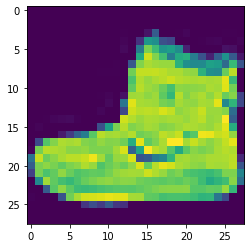

In [15]:
plt.imshow(x_train[0])

- 신발..?

In [16]:
y_train[0] # 신발=9 

9

In [17]:
np.where(y_train==9)

(array([    0,    11,    15, ..., 59932, 59970, 59978]),)

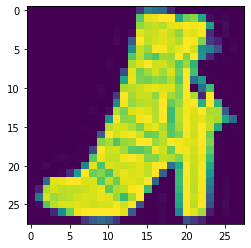

In [18]:
plt.imshow(x_train[11])

- 신발!

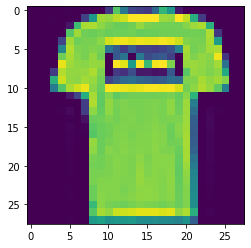

In [19]:
plt.imshow(x_train[1])

In [20]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

## 예제1

`-` y=0,1에 대응하는 이미지만 정리하자. (우리가 배운건 로지스틱이니깐) 

(예비학습코드)

In [21]:
np.array([True,False,True,False,]) | np.array([True,True,False,False])

array([ True,  True,  True, False])

In [22]:
X = x_train[(y_train==1) | (y_train==0)].reshape(-1,28*28)
y = y_train[(y_train==1) | (y_train==0)].reshape(-1,1)
XX = x_test[(y_test==1) | (y_test==0)].reshape(-1,28*28)
yy = y_test[(y_test==1) | (y_test==0)].reshape(-1,1)

In [23]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='sgd',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=500,batch_size=12000) 

2022-05-04 21:24:18.276245: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-05-04 21:24:18.276693: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-04 21:24:18.276900: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-04 21:24:18.277037: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

Epoch 1/500
1/1 [==============================] - 1s 550ms/step - loss: 23.6410
Epoch 2/500
1/1 [==============================] - 0s 2ms/step - loss: 2048.4263
Epoch 3/500
1/1 [==============================] - 0s 2ms/step - loss: 10669.9590
Epoch 4/500
1/1 [==============================] - 0s 2ms/step - loss: 1531.8020
Epoch 5/500
1/1 [==============================] - 0s 2ms/step - loss: 555.8608
Epoch 6/500
1/1 [==============================] - 0s 2ms/step - loss: 214.4535
Epoch 7/500
1/1 [==============================] - 0s 2ms/step - loss: 180.1080
Epoch 8/500
1/1 [==============================] - 0s 3ms/step - loss: 167.2025
Epoch 9/500
1/1 [==============================] - 0s 3ms/step - loss: 156.5934
Epoch 10/500
1/1 [==============================] - 0s 3ms/step - loss: 146.5202
Epoch 11/500
1/1 [==============================] - 0s 2ms/step - loss: 137.1045
Epoch 12/500
1/1 [==============================] - 0s 3ms/step - loss: 128.0816
Epoch 13/500
1/1 [==============

In [24]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9875833333333334

In [25]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.9845

### **풀이1: 은닉층을 포함한 신경망**

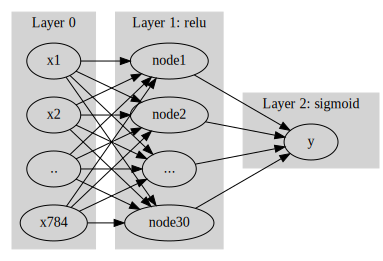

In [26]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "y"
    "node2" -> "y"
    "..." -> "y"
    "node30" -> "y"
    label = "Layer 2: sigmoid"
}
''')

In [27]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='sgd',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 106ms/step - loss: 32.5990
Epoch 2/100
1/1 [==============================] - 0s 2ms/step - loss: 6041.3999
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 45281.3867
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 0.9925
Epoch 5/100
1/1 [==============================] - 0s 3ms/step - loss: 0.8082
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 0.7355
Epoch 7/100
1/1 [==============================] - 0s 3ms/step - loss: 0.6921
Epoch 8/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6902
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6856
Epoch 10/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6699
Epoch 11/100
1/1 [==============================] - 0s 2ms/step - loss: 0.6111
Epoch 12/100
1/1 [==============================] - 0s 2ms/step - loss: 0.5366
Epoch 13/100
1/1 [==============================] -

2022-05-04 21:24:22.793712: I tensorflow/stream_executor/cuda/cuda_blas.cc:1774] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


Epoch 62/100
1/1 [==============================] - 0s 3ms/step - loss: 0.4158
Epoch 63/100
1/1 [==============================] - 0s 2ms/step - loss: 0.4127
Epoch 64/100
1/1 [==============================] - 0s 2ms/step - loss: 0.4102
Epoch 65/100
1/1 [==============================] - 0s 2ms/step - loss: 0.4079
Epoch 66/100
1/1 [==============================] - 0s 3ms/step - loss: 0.4058
Epoch 67/100
1/1 [==============================] - 0s 3ms/step - loss: 0.4038
Epoch 68/100
1/1 [==============================] - 0s 3ms/step - loss: 0.4020
Epoch 69/100
1/1 [==============================] - 0s 3ms/step - loss: 0.4002
Epoch 70/100
1/1 [==============================] - 0s 2ms/step - loss: 0.3986
Epoch 71/100
1/1 [==============================] - 0s 3ms/step - loss: 0.3970
Epoch 72/100
1/1 [==============================] - 0s 4ms/step - loss: 0.3956
Epoch 73/100
1/1 [==============================] - 0s 3ms/step - loss: 0.3941
Epoch 74/100
1/1 [==============================] - 

- 에폭100말고 좀 더 기회주면 잘맞추긴하는데 이정도에서 정리하자. 

In [28]:
np.mean(y == (net(X)>0.5)) , np.mean(yy== (net(XX)> 0.5)) 

(0.9500833333333333, 0.944)

In [29]:
np.mean(y == (net.predict(X)>0.5)) , np.mean(yy== (net.predict(XX)> 0.5))  ## 같은코드 

(0.9500833333333333, 0.944)

### **풀이2: 옵티마이저 개선**

In [30]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy)
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 121ms/step - loss: 32.5990
Epoch 2/100
1/1 [==============================] - 0s 2ms/step - loss: 62.4860
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 22.2779
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 5.6633
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 8.1099
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 12.8664
Epoch 7/100
1/1 [==============================] - 0s 3ms/step - loss: 11.2432
Epoch 8/100
1/1 [==============================] - 0s 2ms/step - loss: 7.4865
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 5.1795
Epoch 10/100
1/1 [==============================] - 0s 2ms/step - loss: 4.3302
Epoch 11/100
1/1 [==============================] - 0s 2ms/step - loss: 4.2608
Epoch 12/100
1/1 [==============================] - 0s 2ms/step - loss: 4.4692
Epoch 13/100
1/1 [==============================] - 0s

In [31]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9851666666666666

In [32]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.979

### **풀이3: 컴파일시 metrics=['accuracy'] 추가**

In [33]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy, metrics=['accuracy'])
net.fit(X,y,epochs=100,batch_size=12000) 

Epoch 1/100
1/1 [==============================] - 0s 174ms/step - loss: 32.5990 - accuracy: 0.4780
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 62.4860 - accuracy: 0.5049
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 22.2779 - accuracy: 0.6697
Epoch 4/100
1/1 [==============================] - 0s 2ms/step - loss: 5.6633 - accuracy: 0.9117
Epoch 5/100
1/1 [==============================] - 0s 3ms/step - loss: 8.1099 - accuracy: 0.8633
Epoch 6/100
1/1 [==============================] - 0s 2ms/step - loss: 12.8664 - accuracy: 0.8176
Epoch 7/100
1/1 [==============================] - 0s 3ms/step - loss: 11.2432 - accuracy: 0.8454
Epoch 8/100
1/1 [==============================] - 0s 2ms/step - loss: 7.4865 - accuracy: 0.8931
Epoch 9/100
1/1 [==============================] - 0s 2ms/step - loss: 5.1795 - accuracy: 0.9256
Epoch 10/100
1/1 [==============================] - 0s 2ms/step - loss: 4.3302 - accuracy: 0.9439
Epoch 11/100
1/1 [====

In [34]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9851666666666666

In [35]:
net.evaluate(X,y)

375/375 [==============================] - 0s 741us/step - loss: 0.6171 - accuracy: 0.9852


[0.6171497702598572, 0.9851666688919067]

In [36]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.979

In [37]:
net.evaluate(XX,yy)

63/63 [==============================] - 0s 1ms/step - loss: 0.8387 - accuracy: 0.9790


[0.8387266993522644, 0.9789999723434448]

### 풀이4: 확률적경사하강법 이용

In [38]:
tf.random.set_seed(43054) # 43054
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(1,activation='sigmoid'))
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy, metrics=['accuracy'])
net.fit(X,y,epochs=10,batch_size=1200) 

Epoch 1/10
10/10 [==============================] - 0s 1ms/step - loss: 16.8980 - accuracy: 0.7893
Epoch 2/10
10/10 [==============================] - 0s 1ms/step - loss: 3.8569 - accuracy: 0.9572
Epoch 3/10
10/10 [==============================] - 0s 1ms/step - loss: 1.8241 - accuracy: 0.9674
Epoch 4/10
10/10 [==============================] - 0s 1ms/step - loss: 1.2484 - accuracy: 0.9783
Epoch 5/10
10/10 [==============================] - 0s 1ms/step - loss: 1.0140 - accuracy: 0.9809
Epoch 6/10
10/10 [==============================] - 0s 1ms/step - loss: 0.8932 - accuracy: 0.9817
Epoch 7/10
10/10 [==============================] - 0s 1ms/step - loss: 0.8039 - accuracy: 0.9824
Epoch 8/10
10/10 [==============================] - 0s 1ms/step - loss: 0.7420 - accuracy: 0.9827
Epoch 9/10
10/10 [==============================] - 0s 980us/step - loss: 0.6975 - accuracy: 0.9835
Epoch 10/10
10/10 [==============================] - 0s 1ms/step - loss: 0.6637 - accuracy: 0.9840


In [39]:
np.mean(y == (net(X)>0.5)) # 거의 100퍼..

0.9845833333333334

In [40]:
net.evaluate(X,y)

375/375 [==============================] - 0s 704us/step - loss: 0.6281 - accuracy: 0.9846


[0.6280956268310547, 0.98458331823349]

In [41]:
np.mean(yy== (net(XX)> 0.5)) # test err도 나쁘지 않아

0.9815

In [42]:
net.evaluate(XX,yy)

63/63 [==============================] - 0s 893us/step - loss: 0.8386 - accuracy: 0.9815


[0.8386226296424866, 0.9815000295639038]

### yhat을 만드는 과정 복습 

In [43]:
## 1
net = tf.keras.Sequential()
## 2 
net.add(tf.keras.layers.Dense(30))
net.add(tf.keras.layers.Activation(tf.nn.relu))
net.add(tf.keras.layers.Dense(1))
net.add(tf.keras.layers.Activation(tf.nn.sigmoid))
## 3 
net.compile(optimizer='adam',loss=tf.losses.binary_crossentropy,metrics=['accuracy']) 
## 4 
net.fit(X,y,epochs=500,verbose=0,batch_size=12000)

In [44]:
l1,a1,l2,a2 = net.layers

In [45]:
l2(a1(l1(X)))

<tf.Tensor: shape=(12000, 1), dtype=float32, numpy=
array([[-470.83728],
       [ -20.22706],
       [ -74.14851],
       ...,
       [ 172.50868],
       [  44.51054],
       [-131.55948]], dtype=float32)>

In [46]:
a2(l2(a1(l1(X))))

<tf.Tensor: shape=(12000, 1), dtype=float32, numpy=
array([[0.0000000e+00],
       [1.6424772e-09],
       [6.2763853e-33],
       ...,
       [1.0000000e+00],
       [1.0000000e+00],
       [0.0000000e+00]], dtype=float32)>

In [47]:
np.exp(-213.75027)

1.4771929751182097e-93

## 예제2

`-` 다중분류문제 

In [48]:
X = x_train.reshape(-1,28*28)
y = y_train.reshape(-1,1) 
XX = x_test.reshape(-1,28*28)
yy = y_test.reshape(-1,1) 

In [49]:
y

array([[9],
       [0],
       [0],
       ...,
       [3],
       [0],
       [5]], dtype=uint8)

- $y=0,1,2\dots,9$

In [50]:
tf.keras.utils.to_categorical(y)

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

`-` y와 yy를 원핫인코딩으로 변환 

In [51]:
y=tf.keras.utils.to_categorical(y)
yy=tf.keras.utils.to_categorical(yy)

### 풀이1: 아까 예제1 정도의 모델로!

In [52]:
X.shape

(60000, 784)

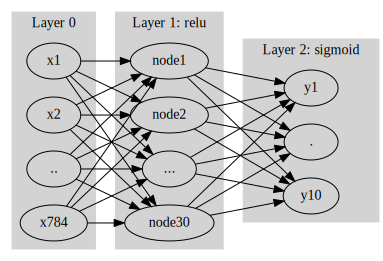

In [53]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node30"
    "x2" -> "node30"
    ".." -> "node30"
    "x784" -> "node30"


    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;

    "node1" -> "y10"
    "node2" -> "y10"
    "..." -> "y10"
    "node30" -> "y10"
    
    "node1" -> "y1"
    "node2" -> "y1"
    "..." -> "y1"
    "node30" -> "y1"
    
    "node1" -> "."
    "node2" -> "."
    "..." -> "."
    "node30" -> "."
    
    label = "Layer 2: sigmoid"
}
''')

In [54]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(30,activation='relu'))
net.add(tf.keras.layers.Dense(10,activation='softmax'))
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=20,batch_size=600) 

Epoch 1/20
100/100 [==============================] - 0s 1ms/step - loss: 15.2989 - accuracy: 0.4801
Epoch 2/20
100/100 [==============================] - 0s 1ms/step - loss: 1.8916 - accuracy: 0.4550
Epoch 3/20
100/100 [==============================] - 0s 1ms/step - loss: 1.6494 - accuracy: 0.4969
Epoch 4/20
100/100 [==============================] - 0s 987us/step - loss: 1.5121 - accuracy: 0.5307
Epoch 5/20
100/100 [==============================] - 0s 1ms/step - loss: 1.3805 - accuracy: 0.5591
Epoch 6/20
100/100 [==============================] - 0s 960us/step - loss: 1.2827 - accuracy: 0.5757
Epoch 7/20
100/100 [==============================] - 0s 993us/step - loss: 1.2101 - accuracy: 0.5873
Epoch 8/20
100/100 [==============================] - 0s 1ms/step - loss: 1.1511 - accuracy: 0.5990
Epoch 9/20
100/100 [==============================] - 0s 1ms/step - loss: 1.1012 - accuracy: 0.6097
Epoch 10/20
100/100 [==============================] - 0s 943us/step - loss: 1.0608 - accurac

In [55]:
net.evaluate(XX,yy)

313/313 [==============================] - 0s 908us/step - loss: 0.9041 - accuracy: 0.6806


[0.9041443467140198, 0.6805999875068665]

### 풀이2: 더 깊은 신경망 

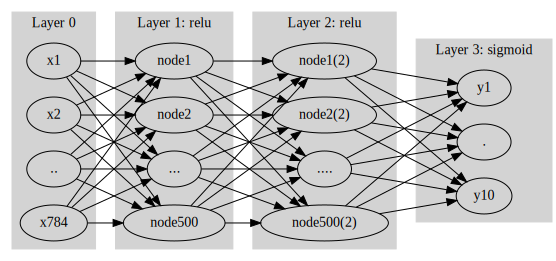

In [56]:
gv('''
splines=line
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x1"
    "x2"
    ".."
    "x784"
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x1" -> "node1"
    "x2" -> "node1"
    ".." -> "node1"
    
    "x784" -> "node1"
    "x1" -> "node2"
    "x2" -> "node2"
    ".." -> "node2"
    "x784" -> "node2"
    
    "x1" -> "..."
    "x2" -> "..."
    ".." -> "..."
    "x784" -> "..."

    "x1" -> "node500"
    "x2" -> "node500"
    ".." -> "node500"
    "x784" -> "node500"


    label = "Layer 1: relu"
}

subgraph cluster_3{
    style=filled;
    color=lightgrey;

    "node1" -> "node1(2)"
    "node2" -> "node1(2)"
    "..." -> "node1(2)"
    "node500" -> "node1(2)"

    "node1" -> "node2(2)"
    "node2" -> "node2(2)"
    "..." -> "node2(2)"
    "node500" -> "node2(2)"
    
    "node1" -> "...."
    "node2" -> "...."
    "..." -> "...."
    "node500" -> "...."
    
    "node1" -> "node500(2)"
    "node2" -> "node500(2)"
    "..." -> "node500(2)"
    "node500" -> "node500(2)"

    
    label = "Layer 2: relu"
}

subgraph cluster_4{
    style=filled;
    color=lightgrey;

    "node1(2)" -> "y10"
    "node2(2)" -> "y10"
    "...." -> "y10"
    "node500(2)" -> "y10"
    
    "node1(2)" -> "y1"
    "node2(2)" -> "y1"
    "...." -> "y1"
    "node500(2)" -> "y1"
    
    "node1(2)" -> "."
    "node2(2)" -> "."
    "...." -> "."
    "node500(2)" -> "."
    
    label = "Layer 3: sigmoid"
}
''')

In [57]:
X.shape

(60000, 784)

In [58]:
net = tf.keras.Sequential()
net.add(tf.keras.layers.Dense(500,activation='relu'))
net.add(tf.keras.layers.Dense(500,activation='relu'))
net.add(tf.keras.layers.Dense(10,activation='softmax'))
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=20,batch_size=600) 

Epoch 1/20
100/100 [==============================] - 0s 1ms/step - loss: 11.1712 - accuracy: 0.7346
Epoch 2/20
100/100 [==============================] - 0s 1ms/step - loss: 1.3446 - accuracy: 0.8172
Epoch 3/20
100/100 [==============================] - 0s 1ms/step - loss: 0.8628 - accuracy: 0.8324
Epoch 4/20
100/100 [==============================] - 0s 1ms/step - loss: 0.6429 - accuracy: 0.8475
Epoch 5/20
100/100 [==============================] - 0s 1ms/step - loss: 0.4984 - accuracy: 0.8614
Epoch 6/20
100/100 [==============================] - 0s 1ms/step - loss: 0.4192 - accuracy: 0.8727
Epoch 7/20
100/100 [==============================] - 0s 1ms/step - loss: 0.3882 - accuracy: 0.8776
Epoch 8/20
100/100 [==============================] - 0s 1ms/step - loss: 0.3427 - accuracy: 0.8872
Epoch 9/20
100/100 [==============================] - 0s 1ms/step - loss: 0.3143 - accuracy: 0.8927
Epoch 10/20
100/100 [==============================] - 0s 1ms/step - loss: 0.2914 - accuracy: 0.899

In [59]:
net.evaluate(XX,yy)

313/313 [==============================] - 0s 935us/step - loss: 0.6448 - accuracy: 0.8507


[0.6447537541389465, 0.8507000207901001]

In [60]:
net.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_13 (Dense)            (None, 500)               392500    
                                                                 
 dense_14 (Dense)            (None, 500)               250500    
                                                                 
 dense_15 (Dense)            (None, 10)                5010      
                                                                 
Total params: 648,010
Trainable params: 648,010
Non-trainable params: 0
_________________________________________________________________


`-` summary상은 힘들어 보인다. 

### 풀이3: CNN

In [61]:
X = tf.constant(x_train.reshape(-1,28,28,1),dtype=tf.float64)
y = tf.constant(tf.keras.utils.to_categorical(y_train),dtype=tf.float64)
XX = tf.constant(x_test.reshape(-1,28,28,1),dtype=tf.float64)
yy = tf.constant(tf.keras.utils.to_categorical(y_test),dtype=tf.float64)

In [62]:
tf.random.set_seed(43052)
net = tf.keras.Sequential()
net.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net.add(tf.keras.layers.MaxPool2D((2,2)))
net.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net.add(tf.keras.layers.MaxPool2D((2,2)))
net.add(tf.keras.layers.Flatten())
net.add(tf.keras.layers.Dense(10,activation='softmax'))

In [63]:
net.compile(optimizer='adam',loss=tf.losses.categorical_crossentropy,metrics=['accuracy']) 
net.fit(X,y,epochs=20,batch_size=600) 

Epoch 1/20


2022-05-04 21:24:48.958807: I tensorflow/stream_executor/cuda/cuda_dnn.cc:366] Loaded cuDNN version 8201
2022-05-04 21:24:49.743267: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-05-04 21:24:49.743408: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-05-04 21:24:49.743418: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2022-05-04 21:24:49.743586: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2022-05-04 21:24:49.743630: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


100/100 [==============================] - 2s 3ms/step - loss: 3.6706 - accuracy: 0.5977
Epoch 2/20
100/100 [==============================] - 0s 3ms/step - loss: 0.6956 - accuracy: 0.7702
Epoch 3/20
100/100 [==============================] - 0s 3ms/step - loss: 0.5477 - accuracy: 0.8139
Epoch 4/20
100/100 [==============================] - 0s 3ms/step - loss: 0.4747 - accuracy: 0.8368
Epoch 5/20
100/100 [==============================] - 0s 3ms/step - loss: 0.4279 - accuracy: 0.8518
Epoch 6/20
100/100 [==============================] - 0s 3ms/step - loss: 0.3985 - accuracy: 0.8613
Epoch 7/20
100/100 [==============================] - 0s 3ms/step - loss: 0.3695 - accuracy: 0.8703
Epoch 8/20
100/100 [==============================] - 0s 3ms/step - loss: 0.3461 - accuracy: 0.8773
Epoch 9/20
100/100 [==============================] - 0s 3ms/step - loss: 0.3329 - accuracy: 0.8813
Epoch 10/20
100/100 [==============================] - 0s 3ms/step - loss: 0.3149 - accuracy: 0.8889
Epoch 11/2

In [64]:
net.evaluate(XX,yy)

313/313 [==============================] - 0s 1ms/step - loss: 0.3860 - accuracy: 0.8741


[0.38598543405532837, 0.8741000294685364]

In [65]:
net.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 30)        780       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 30)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 30)          22530     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 30)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 480)               0         
                                                                 
 dense_16 (Dense)            (None, 10)               